In [17]:
#import df.to_csv('full_merged_cleaned_low_corr.csv', index=False)

import pandas as pd

df = pd.read_csv('full_merged_cleaned_low_corr.csv')
df.head()


,home_team,away_team,Winner_HoAw,age_home,jumping_home,gk_diving_home,gk_kicking_home,stamina_away,jumping_away,gk_diving_away,gk_kicking_away
0,Germany,Scotland,Home,25.0,70.0,11.0,9.0,71.5,66.5,11.5,10.0
1,Hungary,Switzerland,Away,27.0,64.0,11.0,11.0,67.5,68.0,11.5,9.0
2,Spain,Croatia,Home,27.5,62.0,11.0,10.5,60.5,61.5,11.5,10.0
3,Italy,Albania,Home,27.0,70.5,12.0,10.5,68.0,66.0,12.0,12.0
4,Poland,Netherlands,Away,27.5,65.5,11.0,12.5,66.0,66.0,10.0,11.5


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   home_team        36 non-null     object 
 1   away_team        36 non-null     object 
 2   Winner_HoAw      36 non-null     object 
 3   age_home         36 non-null     float64
 4   jumping_home     36 non-null     float64
 5   gk_diving_home   36 non-null     float64
 6   gk_kicking_home  36 non-null     float64
 7   stamina_away     36 non-null     float64
 8   jumping_away     36 non-null     float64
 9   gk_diving_away   36 non-null     float64
 10  gk_kicking_away  36 non-null     float64
dtypes: float64(8), object(3)
memory usage: 3.2+ KB


In [19]:
#unique home team names
df['home_team'].unique()

array(['Germany', 'Hungary', 'Spain', 'Italy', 'Poland', 'Slovenia',
       'Serbia', 'Romania', 'Belgium', 'Austria', 'Türkiye', 'Portugal',
       'Croatia', 'Scotland', 'Denmark', 'Slovakia', 'Netherlands',
       'Georgia', 'Switzerland', 'Albania', 'France', 'England',
       'Ukraine', 'Czechia'], dtype=object)

In [20]:
import pandas as pd

# Define the teams and their Power Rankings in the correct order
data_rankings = {
    "team": ['Spain', 'Germany', 'Austria', 'France', 'Portugal', 'Switzerland', 'Georgia', 'Türkiye', 'England', 
             'Belgium', 'Italy', 'Netherlands', 'Denmark', 'Romania', 'Slovakia', 'Slovenia', 'Ukraine', 'Croatia', 
             'Albania', 'Hungary', 'Czechia', 'Poland', 'Serbia', 'Scotland'],
    "Power_Rankings": list(range(1, 25))  # Rankings from 1 to 24
}

# Convert to DataFrame
rankings_df = pd.DataFrame(data_rankings)

# Calculate Scaled_Power_Rankings
rankings_df["Scaled_Power_Rankings"] = 1 - (rankings_df["Power_Rankings"] - 1) / (len(rankings_df) - 1)

In [21]:
rankings_df.head(36)

,team,Power_Rankings,Scaled_Power_Rankings
0,Spain,1,1.000000
1,Germany,2,0.956522
2,Austria,3,0.913043
3,France,4,0.869565
4,Portugal,5,0.826087
5,Switzerland,6,0.782609
6,Georgia,7,0.739130
7,Türkiye,8,0.695652
8,England,9,0.652174
9,Belgium,10,0.608696


In [22]:

# Merge for home_team and away_team with suffixes
df = df.merge(rankings_df, how='left', left_on='home_team', right_on='team', suffixes=('', '_home'))
df = df.merge(rankings_df, how='left', left_on='away_team', right_on='team', suffixes=('', '_away'))

# Rename the merged columns appropriately
df = df.rename(columns={
    'Power_Rankings': 'Power_Rankings_home',
    'Scaled_Power_Rankings': 'Scaled_Power_Rankings_home',
    'Power_Rankings_away': 'Power_Rankings_away',
    'Scaled_Power_Rankings_away': 'Scaled_Power_Rankings_away'
})

# Drop the redundant 'team' columns
df = df.drop(columns=['team', 'team_away'])

# Display the resulting DataFrame
print(df)

      home_team    away_team Winner_HoAw  age_home  jumping_home  \
0       Germany     Scotland        Home      25.0          70.0   
1       Hungary  Switzerland        Away      27.0          64.0   
2         Spain      Croatia        Home      27.5          62.0   
3         Italy      Albania        Home      27.0          70.5   
4        Poland  Netherlands        Away      27.5          65.5   
5      Slovenia      Denmark        Draw      27.0          69.0   
6        Serbia      England        Away      28.0          66.5   
7       Romania      Ukraine        Home      28.0          70.0   
8       Belgium     Slovakia        Away      24.0          69.5   
9       Austria       France        Away      26.5          62.5   
10      Türkiye      Georgia        Home      27.0          64.5   
11     Portugal      Czechia        Home      25.0          61.5   
12      Croatia      Albania        Draw      27.0          61.5   
13      Germany      Hungary        Home      25

In [23]:
df.head()

,home_team,away_team,Winner_HoAw,age_home,jumping_home,gk_diving_home,gk_kicking_home,stamina_away,jumping_away,gk_diving_away,gk_kicking_away,Power_Rankings_home,Scaled_Power_Rankings_home,Power_Rankings_away,Scaled_Power_Rankings_away
0,Germany,Scotland,Home,25.0,70.0,11.0,9.0,71.5,66.5,11.5,10.0,2,0.956522,24,0.000000
1,Hungary,Switzerland,Away,27.0,64.0,11.0,11.0,67.5,68.0,11.5,9.0,20,0.173913,6,0.782609
2,Spain,Croatia,Home,27.5,62.0,11.0,10.5,60.5,61.5,11.5,10.0,1,1.000000,18,0.260870
3,Italy,Albania,Home,27.0,70.5,12.0,10.5,68.0,66.0,12.0,12.0,11,0.565217,19,0.217391
4,Poland,Netherlands,Away,27.5,65.5,11.0,12.5,66.0,66.0,10.0,11.5,22,0.086957,12,0.521739


In [24]:
#drop Power_Rankings_home and Power_Rankings_away
df = df.drop(columns=['Power_Rankings_home', 'Power_Rankings_away'])

In [25]:
df.head()

,home_team,away_team,Winner_HoAw,age_home,jumping_home,gk_diving_home,gk_kicking_home,stamina_away,jumping_away,gk_diving_away,gk_kicking_away,Scaled_Power_Rankings_home,Scaled_Power_Rankings_away
0,Germany,Scotland,Home,25.0,70.0,11.0,9.0,71.5,66.5,11.5,10.0,0.956522,0.000000
1,Hungary,Switzerland,Away,27.0,64.0,11.0,11.0,67.5,68.0,11.5,9.0,0.173913,0.782609
2,Spain,Croatia,Home,27.5,62.0,11.0,10.5,60.5,61.5,11.5,10.0,1.000000,0.260870
3,Italy,Albania,Home,27.0,70.5,12.0,10.5,68.0,66.0,12.0,12.0,0.565217,0.217391
4,Poland,Netherlands,Away,27.5,65.5,11.0,12.5,66.0,66.0,10.0,11.5,0.086957,0.521739


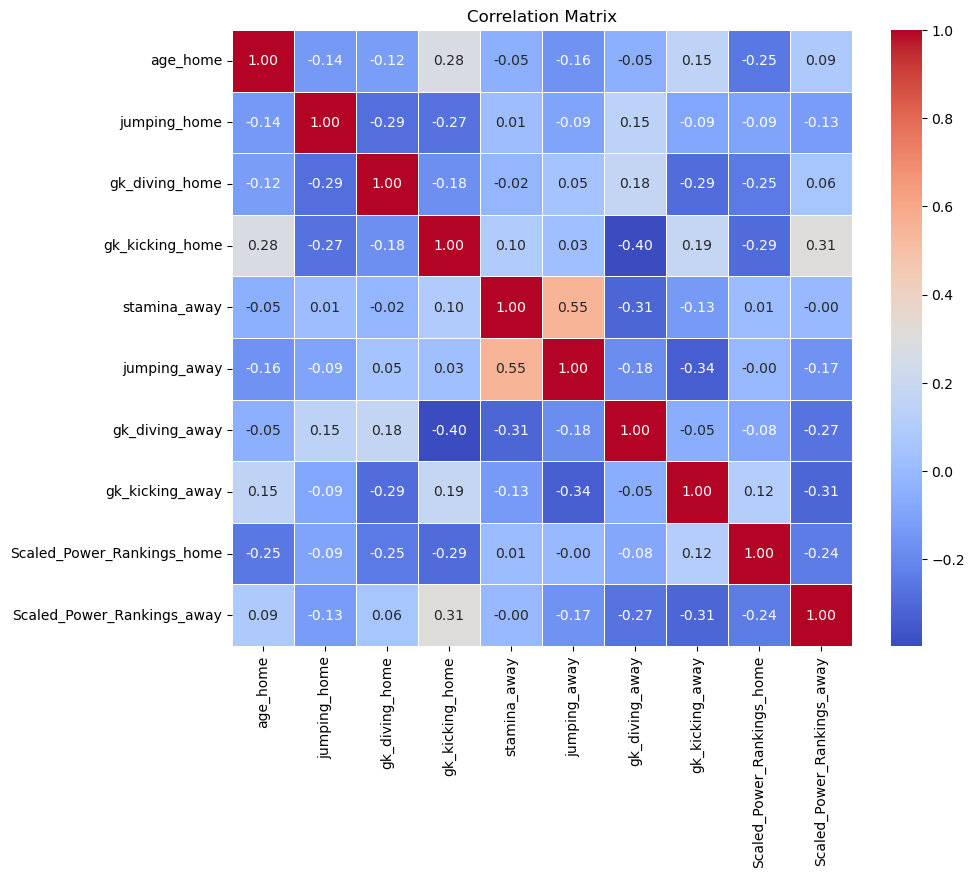

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df is your DataFrame

# Select only the numeric columns
numeric_df = df.select_dtypes(include='number')

# Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

# Plot the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

In [27]:
#use X and Y to train the model
X = df.drop(['Winner_HoAw'], axis=1)
Y = df['Winner_HoAw']

In [28]:
#show X values
X.head(38)

,home_team,away_team,age_home,jumping_home,gk_diving_home,gk_kicking_home,stamina_away,jumping_away,gk_diving_away,gk_kicking_away,Scaled_Power_Rankings_home,Scaled_Power_Rankings_away
0,Germany,Scotland,25.0,70.0,11.0,9.0,71.5,66.5,11.5,10.0,0.956522,0.000000
1,Hungary,Switzerland,27.0,64.0,11.0,11.0,67.5,68.0,11.5,9.0,0.173913,0.782609
2,Spain,Croatia,27.5,62.0,11.0,10.5,60.5,61.5,11.5,10.0,1.000000,0.260870
3,Italy,Albania,27.0,70.5,12.0,10.5,68.0,66.0,12.0,12.0,0.565217,0.217391
4,Poland,Netherlands,27.5,65.5,11.0,12.5,66.0,66.0,10.0,11.5,0.086957,0.521739
5,Slovenia,Denmark,27.0,69.0,10.5,11.5,71.5,72.0,11.0,10.0,0.347826,0.478261
6,Serbia,England,28.0,66.5,11.0,13.0,67.5,67.5,10.5,10.0,0.043478,0.652174
7,Romania,Ukraine,28.0,70.0,9.5,9.5,63.5,59.0,12.0,12.0,0.434783,0.304348
8,Belgium,Slovakia,24.0,69.5,11.0,11.0,59.0,60.5,12.5,10.5,0.608696,0.391304
9,Austria,France,26.5,62.5,10.5,12.5,65.0,64.0,10.0,11.5,0.913043,0.869565


In [29]:
#shape of X and Y
X.shape

(36, 12)

## Using random forest

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Encode categorical variables
X_encoded = pd.get_dummies(X, columns=['home_team', 'away_team'])

# Split the data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X_encoded, Y, test_size=0.2, random_state=42)

# Initialize and train the model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, Y_train)

# Make predictions on the test set
Y_pred = model.predict(X_test)

# Calculate and print the accuracy
accuracy = accuracy_score(Y_test, Y_pred)
print(f'Accuracy: {accuracy:.2f}')


Accuracy: 0.50


## Deep Learning  Models

In [31]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split

# Assuming X and Y are your input and target DataFrames
# Encode categorical variables in X
X_encoded = pd.get_dummies(X, columns=['home_team', 'away_team'])

# Fill any missing values with 0 or an appropriate value
X_encoded = X_encoded.fillna(0)

# Ensure all data in X_encoded is of numeric type
X_encoded = X_encoded.astype(float)

# Encode the target variable Y
Y_encoded = pd.get_dummies(Y)

# Split the data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X_encoded, Y_encoded, test_size=0.2, random_state=42)

# Initialize the model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(Y_train.shape[1], activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, Y_train, epochs=50, batch_size=8, validation_split=0.2)

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, Y_test)
print(f'Test Accuracy: {test_accuracy:.2f}')



Epoch 1/50
3/3 [==============================] - 0s 70ms/step - loss: 5.3725 - accuracy: 0.3636 - val_loss: 7.5057 - val_accuracy: 0.1667
Epoch 2/50
3/3 [==============================] - 0s 9ms/step - loss: 3.8483 - accuracy: 0.4091 - val_loss: 3.7232 - val_accuracy: 0.3333
Epoch 3/50
3/3 [==============================] - 0s 9ms/step - loss: 2.0211 - accuracy: 0.4091 - val_loss: 1.0236 - val_accuracy: 0.6667
Epoch 4/50
3/3 [==============================] - 0s 8ms/step - loss: 1.8593 - accuracy: 0.3182 - val_loss: 1.1871 - val_accuracy: 0.5000
Epoch 5/50
3/3 [==============================] - 0s 10ms/step - loss: 1.7094 - accuracy: 0.3182 - val_loss: 1.1722 - val_accuracy: 0.6667
Epoch 6/50
3/3 [==============================] - 0s 12ms/step - loss: 1.0519 - accuracy: 0.4545 - val_loss: 2.2300 - val_accuracy: 0.3333
Epoch 7/50
3/3 [==============================] - 0s 12ms/step - loss: 1.4198 - accuracy: 0.4091 - val_loss: 2.4746 - val_accuracy: 0.1667
Epoch 8/50
3/3 [==============

## Adding layers to Deep Neural Network

In [32]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split

# Encode categorical variables in X
X_encoded = pd.get_dummies(X, columns=['home_team', 'away_team'])

# Ensure all data in X_encoded is of numeric type and fill any missing values with 0
X_encoded = X_encoded.fillna(0).astype(float)

# Encode the target variable
Y_encoded = pd.get_dummies(Y)

# Split the data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X_encoded, Y_encoded, test_size=0.2, random_state=42)

# Initialize the model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(Y_train.shape[1], activation='softmax')
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, Y_train, epochs=100, batch_size=8, validation_split=0.2)

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, Y_test)
print(f'Test Accuracy: {test_accuracy:.2f}')

# Prepare the input data for the specified games
games_data = [
    {'home_team': 'Switzerland', 'away_team': 'Italy', 'age_home': 27.0, 'jumping_home': 70.5, 'gk_diving_home': 12.0, 'gk_kicking_home': 10.5, 'stamina_away': 67.5, 'jumping_away': 68.0, 'gk_diving_away': 11.5, 'gk_kicking_away': 9.0, 'Scaled_Power_Rankings_home': 0.782609, 'Scaled_Power_Rankings_away': 0.565217, 'result': 'Draw'},
    {'home_team': 'Germany', 'away_team': 'Denmark', 'age_home': 26.5, 'jumping_home': 71.0, 'gk_diving_home': 11.0, 'gk_kicking_home': 11.0, 'stamina_away': 66.5, 'jumping_away': 65.5, 'gk_diving_away': 12.0, 'gk_kicking_away': 10.0, 'Scaled_Power_Rankings_home': 0.956522, 'Scaled_Power_Rankings_away': 0.478261, 'result': 'Draw'},
    {'home_team': 'England', 'away_team': 'Slovakia', 'age_home': 28.0, 'jumping_home': 69.0, 'gk_diving_home': 13.0, 'gk_kicking_home': 12.0, 'stamina_away': 65.0, 'jumping_away': 64.0, 'gk_diving_away': 11.0, 'gk_kicking_away': 9.5, 'Scaled_Power_Rankings_home': 0.652174, 'Scaled_Power_Rankings_away': 0.391304, 'result': 'Away'},
    {'home_team': 'Spain', 'away_team': 'Georgia', 'age_home': 27.5, 'jumping_home': 68.0, 'gk_diving_home': 12.0, 'gk_kicking_home': 11.5, 'stamina_away': 63.0, 'jumping_away': 62.0, 'gk_diving_away': 10.5, 'gk_kicking_away': 10.0, 'Scaled_Power_Rankings_home': 1.0, 'Scaled_Power_Rankings_away': 0.73913, 'result': 'Away'},
    {'home_team': 'France', 'away_team': 'Belgium', 'age_home': 28.0, 'jumping_home': 70.0, 'gk_diving_home': 11.5, 'gk_kicking_home': 12.0, 'stamina_away': 67.0, 'jumping_away': 65.0, 'gk_diving_away': 11.5, 'gk_kicking_away': 10.5, 'Scaled_Power_Rankings_home': 0.869565, 'Scaled_Power_Rankings_away': 0.608696, 'result': 'Draw'},
    {'home_team': 'Portugal', 'away_team': 'Slovenia', 'age_home': 26.0, 'jumping_home': 69.5, 'gk_diving_home': 12.5, 'gk_kicking_home': 11.0, 'stamina_away': 64.5, 'jumping_away': 63.5, 'gk_diving_away': 10.5, 'gk_kicking_away': 10.0, 'Scaled_Power_Rankings_home': 0.826087, 'Scaled_Power_Rankings_away': 0.347826, 'result': 'Away'},
    {'home_team': 'Romania', 'away_team': 'Netherlands', 'age_home': 27.0, 'jumping_home': 67.0, 'gk_diving_home': 11.0, 'gk_kicking_home': 12.0, 'stamina_away': 66.0, 'jumping_away': 67.5, 'gk_diving_away': 12.0, 'gk_kicking_away': 11.0, 'Scaled_Power_Rankings_home': 0.434783, 'Scaled_Power_Rankings_away': 0.521739, 'result': 'Draw'},
    {'home_team': 'Austria', 'away_team': 'Turkey', 'age_home': 26.5, 'jumping_home': 70.0, 'gk_diving_home': 11.5, 'gk_kicking_home': 11.0, 'stamina_away': 65.0, 'jumping_away': 64.0, 'gk_diving_away': 11.0, 'gk_kicking_away': 10.0, 'Scaled_Power_Rankings_home': 0.913043, 'Scaled_Power_Rankings_away': 0.73913, 'result': 'Away'}
]

# Create a DataFrame for the game data
games_df = pd.DataFrame(games_data)

# Encode categorical variables
games_encoded = pd.get_dummies(games_df, columns=['home_team', 'away_team'])

# Ensure the encoded data has the same columns as the training data
X_encoded_columns = X_encoded.columns
missing_cols = set(X_encoded_columns) - set(games_encoded.columns)
for c in missing_cols:
    games_encoded[c] = 0
games_encoded = games_encoded[X_encoded_columns]

# Ensure all data is of numeric type
games_encoded = games_encoded.astype(float)

# Make predictions
predictions = model.predict(games_encoded)
predicted_classes = np.argmax(predictions, axis=1)

# Decode the predicted classes
class_mapping = Y_encoded.columns
predicted_outcomes = [class_mapping[pred] for pred in predicted_classes]

# Print the predicted outcomes for each game
for i, game in enumerate(games_data):
    print(f'Predicted outcome for {game["home_team"]} vs {game["away_team"]}: {predicted_outcomes[i]}')


Epoch 1/100
3/3 [==============================] - 1s 84ms/step - loss: 1.3732 - accuracy: 0.5455 - val_loss: 14.6591 - val_accuracy: 0.3333
Epoch 2/100
3/3 [==============================] - 0s 10ms/step - loss: 1.8119 - accuracy: 0.2273 - val_loss: 13.1914 - val_accuracy: 0.3333
Epoch 3/100
3/3 [==============================] - 0s 11ms/step - loss: 1.4360 - accuracy: 0.4545 - val_loss: 11.7870 - val_accuracy: 0.3333
Epoch 4/100
3/3 [==============================] - 0s 11ms/step - loss: 1.8793 - accuracy: 0.3182 - val_loss: 10.7498 - val_accuracy: 0.3333
Epoch 5/100
3/3 [==============================] - 0s 10ms/step - loss: 1.8361 - accuracy: 0.3636 - val_loss: 9.7760 - val_accuracy: 0.3333
Epoch 6/100
3/3 [==============================] - 0s 11ms/step - loss: 1.1770 - accuracy: 0.5000 - val_loss: 9.0720 - val_accuracy: 0.3333
Epoch 7/100
3/3 [==============================] - 0s 11ms/step - loss: 0.9961 - accuracy: 0.5455 - val_loss: 8.6084 - val_accuracy: 0.1667
Epoch 8/100
3/3 

## Results

With a test accucary of 50 % I was able to predict good results and having 4 out of 8 results correct. Of course there are a lot of factors in Soccer to consider which make accurate predictions very hard, but achievalble nonetheless.

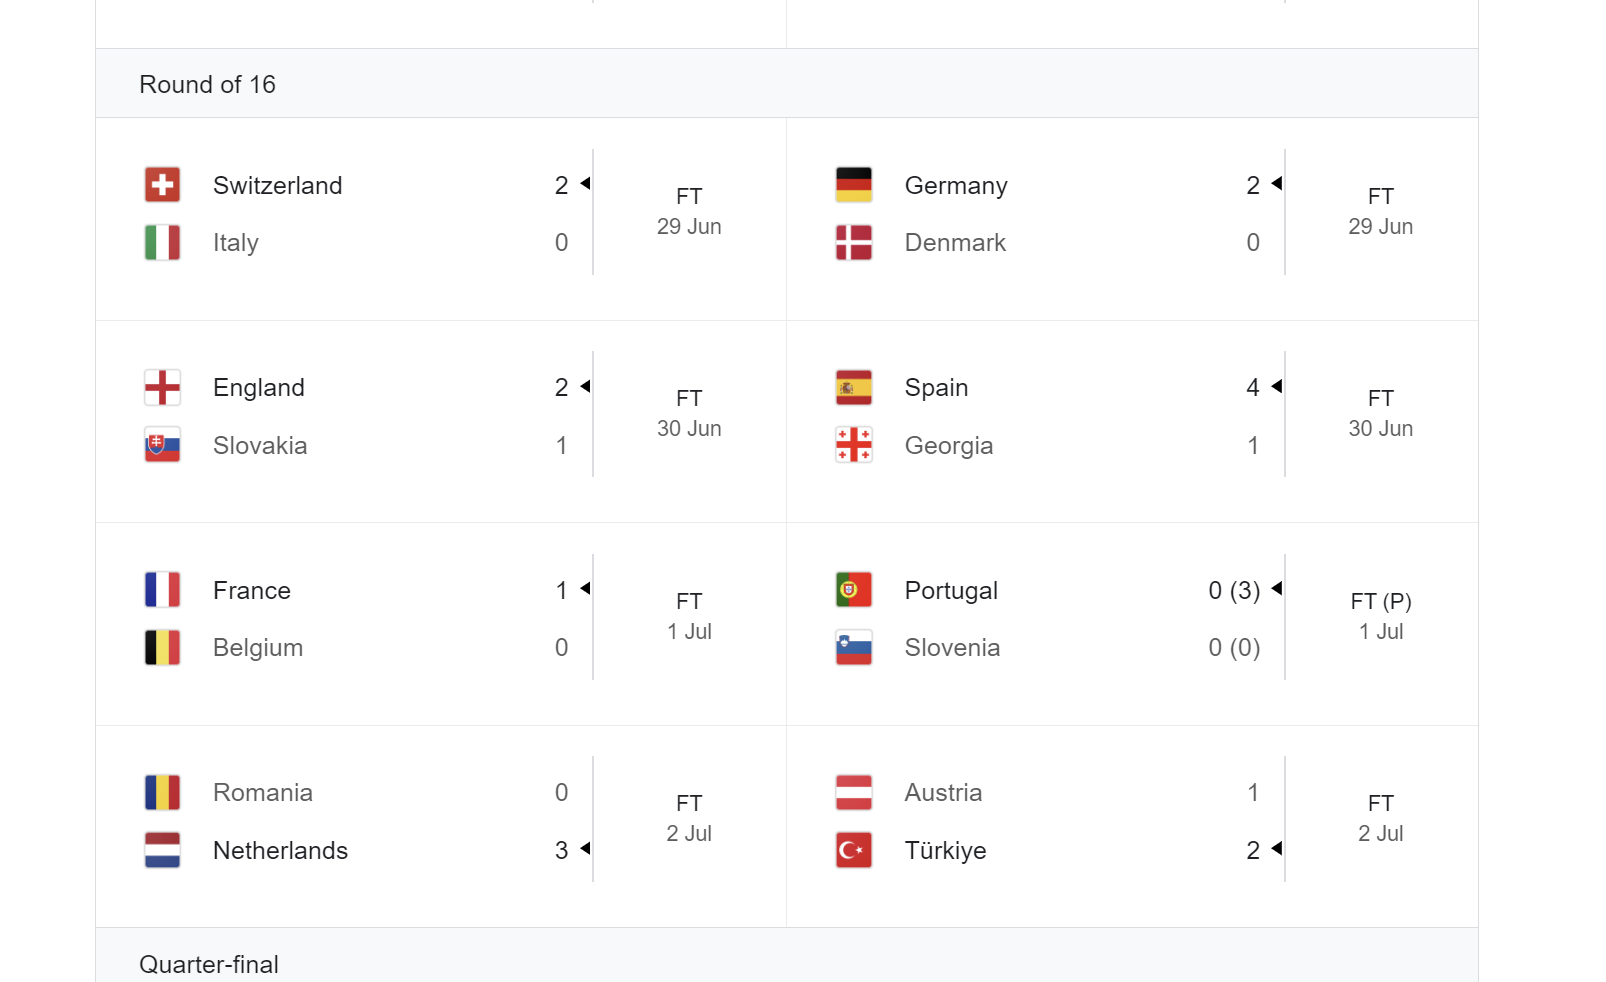